# Simple RPM Trajectory Generator

> Generates sinusoïdal/constant/polynomial trajectory patterns to test RK4 Stokes solver on it. 

In [33]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import datetime

In [34]:
# Init constants 
TRAJ_FOLDER = "data/trajectories"

In [35]:
# Generation functions 

def gen_outer_constant(step_s, duration_s, omega_2): 
    """
    Generate a Clinostat-based trajectory by setting inner 
    axis to zero and rotating outer to theta_2 = ometa_2 cdot t. 
    - step_s : increment timestamp step (second)
    - durations_s : trajectory duration (second)
    - omega_2 : speed (degrees / s)
    """

    # Init numpy matrices 
    timestamp = np.arange(0, duration_s, step_s)
    theta_1 = np.zeros_like(timestamp)
    theta_2 = omega_2 * timestamp

    return np.array([
        timestamp, 
        theta_1, 
        theta_2
    ])


def gen_biaxial_sin(step_s, duration_s, omega): 
    """
    Generate a biaxial harmonic trajectory on the sphere using 
    Leguy et al. system. 
    - step_s : increment timestamp step (second)
    - durations_s : trajectory duration (second)
    - omega : speed (degrees / s)
    """
    THETA_1 = np.radians(20) 
    THETA_2 = np.radians(20) 
    
    timestamp = np.arange(0, duration_s, step_s)
    theta_1 = THETA_1 * np.cos(2 * omega * timestamp) 
    theta_2 = THETA_2 * np.sin(omega * timestamp)

    return np.array([
        timestamp, 
        theta_1, 
        theta_2
    ])


def gen_biaxial_desynchro(step_s, duration_s, omega_1, omega_2): 
    """
    Generate a biaxial desynchronized trajectory. 
    - step_s : increment timestamp step (second)
    - durations_s : trajectory duration (second)
    - omega_1 : speed (degrees / s)
    - omega_2 : speed (degrees / s)
    """
    # Init numpy matrices 
    timestamp = np.arange(0, duration_s, step_s)
    theta_1 = omega_1 * timestamp
    theta_2 = omega_2 * timestamp

    return np.array([
        timestamp, 
        theta_1, 
        theta_2
    ])



In [36]:
# Generate CSV trajectories 

DURATION_S = 2 * 60
STEP_S = 10e-3

traj1 = gen_outer_constant(STEP_S, DURATION_S, omega_2=np.radians(5))
traj2 = gen_biaxial_sin(STEP_S, DURATION_S, omega=np.radians(20))
traj3 = gen_biaxial_desynchro(STEP_S, DURATION_S, omega_1=np.radians(57), omega_2=np.radians(41))


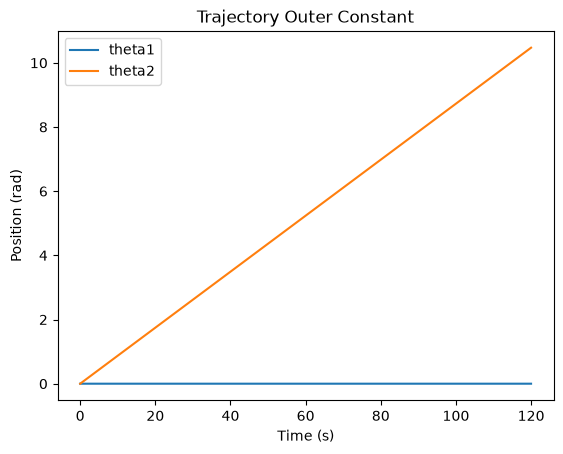

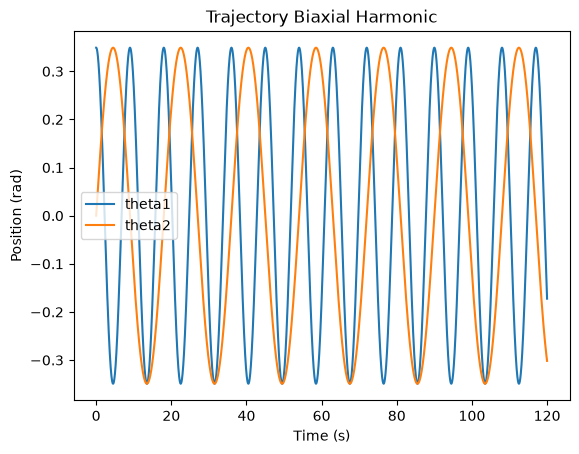

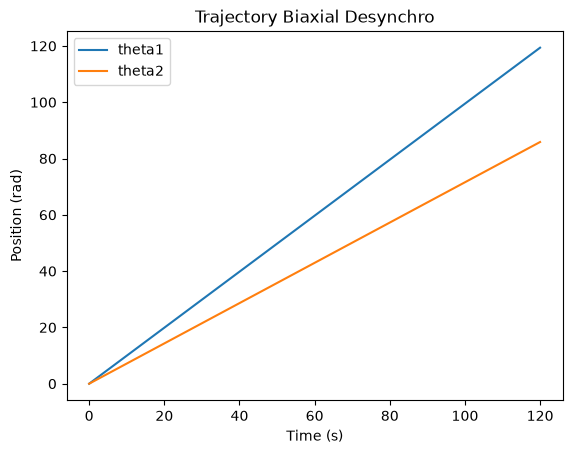

In [37]:
# Plot trajectories 

def plot_traj(traj, name):
    """
    Plot given trajectory using Pyplot. 
    - traj : numpy tensor of the trajectory
    - name : trajectory description (str)
    """
    # Extract arrays 
    t = traj[0]
    theta1 = traj[1]
    theta2 = traj[2]
    # Plot them 
    plt.plot(t, theta1, label="theta1")
    plt.plot(t, theta2, label="theta2")
    plt.ylabel("Position (rad)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.title(f"Trajectory {name}")
    plt.show()

plot_traj(traj1, "Outer Constant")
plot_traj(traj2, "Biaxial Harmonic")
plot_traj(traj3, "Biaxial Desynchro")


In [ ]:
# Write CSV files 

def write_CSV(traj, export_path, traj_desc):
    """
    Write a (3,N) Numpy trajectory into 
    a CSV files. 
    - traj : (3,N) numpy trajectory 
    - export_path : CSV export filepath
    - traj_desc : string trajectory description for 
    CSV file header. 
    """
    # Process metadatas
    duration = traj[0][-1]
    step = traj[0][1] - traj[0][0]
    
    with open(f"../{TRAJ_FOLDER}/{export_path}", "w") as file: 
        # Write header 
        file.write(f"# RPM TRAJECTORY - {traj_desc}\n")
        file.write("# NB : All positions are in radians and steps in seconds.\n")
        file.write(f"# duration_s : {duration}\n")
        file.write(f"# step_s : {step}\n")
        file.write(f"# generation : {datetime.datetime.now()}\n")
        file.write(f"# ============================================== \n")
        file.write(f"timestamp, theta1, theta2\n")


        # Write trajectory 
        np.savetxt(file, traj.T, delimiter=",")

write_CSV(traj1, "traj1_inner_zero.csv", "INNER ZERO / OUTER CONSTANT")
write_CSV(traj2, "traj2_biaxial_harmonic.csv", "BIAXIAL HARMONIC")
write_CSV(traj2, "traj3_biaxial_desynchro.csv", "BIAXIAL DE-SYNCHRONIZED")